In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (

    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.optimizers import (
    Adam,
    RMSprop
)

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv(
    "/content/drive/MyDrive/pjm_processed.csv",
    parse_dates=["timestamp"]
)

In [4]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")

df = df.reset_index(drop=True)

print(df.shape)
print(df.head())

(145224, 18)
            timestamp   demand  hour  day_of_week  month  day  week  year  \
0 2002-01-08 01:00:00  29445.0     1            1      1    8     2  2002   
1 2002-01-08 02:00:00  28670.0     2            1      1    8     2  2002   
2 2002-01-08 03:00:00  28375.0     3            1      1    8     2  2002   
3 2002-01-08 04:00:00  28542.0     4            1      1    8     2  2002   
4 2002-01-08 05:00:00  29261.0     5            1      1    8     2  2002   

   is_weekend    lag_1   lag_48  lag_168  rolling_mean_24  rolling_mean_168  \
0           0  31187.0  27100.0  30393.0     33452.583333      32519.511905   
1           0  29445.0  26097.0  29265.0     33560.208333      32513.869048   
2           0  28670.0  25793.0  28357.0     33672.458333      32510.327381   
3           0  28375.0  25657.0  27899.0     33786.375000      32510.434524   
4           0  28542.0  25778.0  28057.0     33906.208333      32514.261905   

   rolling_std_24  rolling_std_168    period  lag

In [5]:
df["rolling_mean_24"] = (
    df["demand"]
    .shift(1)
    .rolling(24)
    .mean()
)

df["rolling_std_24"] = (
    df["demand"]
    .shift(1)
    .rolling(24)
    .std()
)

df["rolling_mean_48"] = (
    df["demand"]
    .shift(1)
    .rolling(48)
    .mean()
)

df["rolling_std_48"] = (
    df["demand"]
    .shift(1)
    .rolling(48)
    .std()
)

In [6]:
df = df.dropna().reset_index(drop=True)

In [7]:
print(df.isna().sum().sum())

0


In [9]:
test_size = int(len(df) * 0.20)

test_start = len(df) - test_size

remaining = df.iloc[:test_start]

test = df.iloc[test_start:]

In [10]:
validation_hours = 30 * 24

val_start = len(remaining) - validation_hours

train = remaining.iloc[:val_start]

validation = remaining.iloc[val_start:]

In [11]:
print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (115421, 20)
Validation: (720, 20)
Test: (29035, 20)


In [12]:
print(
    "Train:",
    train["timestamp"].min(),
    "to",
    train["timestamp"].max()
)

print(
    "Validation:",
    validation["timestamp"].min(),
    "to",
    validation["timestamp"].max()
)

print(
    "Test:",
    test["timestamp"].min(),
    "to.",
    test["timestamp"].max()
)

Train: 2002-01-10 01:00:00 to 2015-03-12 05:00:00
Validation: 2015-03-12 06:00:00 to 2015-04-11 05:00:00
Test: 2015-04-11 06:00:00 to. 2018-08-03 00:00:00


In [13]:
features = [
    "demand",
    "lag_1",
    "lag_24",
    "lag_48",
    "lag_48",
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_mean_48",
    "rolling_std_48"
]
target_column = "demand"

In [14]:
feature_scaler = MinMaxScaler()

train_scaled = feature_scaler.fit_transform(
    train[features]
)

validation_scaled = feature_scaler.transform(
    validation[features]
)

test_scaled = feature_scaler.transform(
    test[features]
)

In [15]:
target_scaler = MinMaxScaler()

target_train_scaled = target_scaler.fit_transform(
    train[["demand"]]
)

target_validation_scaled = target_scaler.transform(
    validation[["demand"]]
)

target_test_scaled = target_scaler.transform(
    test[["demand"]]
)

In [16]:
def create_multivariate_sequences(
    X_data,
    y_data,
    input_length=48,
    output_length=24
):

    X = []
    y = []

    for i in range(
        len(X_data) - input_length - output_length + 1
    ):

        X.append(
            X_data[
                i:i + input_length
            ]
        )

        y.append(
            y_data[
                i + input_length:
                i + input_length + output_length
            ]
        )

    return np.array(X), np.array(y)

In [17]:
X_train, y_train = create_multivariate_sequences(
    train_scaled,
    target_train_scaled,
    input_length=48,
    output_length=24
)

In [18]:
y_train = y_train.reshape(
    y_train.shape[0],
    24
)

In [19]:
test_X_input = np.concatenate([
    validation_scaled[-48:],
    test_scaled
])

test_y_input = np.concatenate([
    target_validation_scaled[-48:],
    target_test_scaled
])

In [20]:
X_test, y_test = create_multivariate_sequences(
    test_X_input,
    test_y_input,
    input_length=48,
    output_length=24
)

In [21]:
y_test = y_test.reshape(
    y_test.shape[0],
    24
)

In [22]:
# Validation sequences

val_X_input = np.concatenate([
    train_scaled[-48:],
    validation_scaled
])

val_y_input = np.concatenate([
    target_train_scaled[-48:],
    target_validation_scaled
])

X_val, y_val = create_multivariate_sequences(
    val_X_input,
    val_y_input,
    input_length=48,
    output_length=24
)

y_val = y_val.reshape(
    y_val.shape[0],
    24
)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_val: (697, 48, 9)
y_val: (697, 24)


In [23]:
#evaluation func
def evaluate_forecast(y_true, y_pred):

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs(
            (y_true - y_pred) /
            np.where(y_true == 0, 1, y_true)
        )
    ) * 100

    r2 = r2_score(
        y_true,
        y_pred
    )

    bias = np.mean(
        y_pred - y_true
    )

    return mae, mse, rmse, mape, r2, bias

In [24]:
def inverse_target(data):

    original_shape = data.shape

    data = data.reshape(-1, 1)

    data = target_scaler.inverse_transform(
        data
    )

    return data.reshape(original_shape)

In [25]:
def build_RNN_baseline():

    # RNN
    model = Sequential([
        SimpleRNN(64, input_shape=(48, 9)),
        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [26]:
#Early_stop
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [27]:
RNN_features = build_RNN_baseline()

history_features = RNN_features.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=15,
    batch_size=32,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - loss: 0.0038 - val_loss: 0.0023
Epoch 2/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 3/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 4/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 5/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 0.0021 - val_loss: 0.0017
Epoch 6/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 0.0020 - val_loss: 0.0017
Epoch 7/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 8/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0018 - val_loss: 0.0016
Epoch 9/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 10/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 11/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 12/15
3605/36

In [28]:
pred_features = RNN_features.predict(
    X_test,
    verbose=0
)

In [29]:
pred_features = inverse_target(
    pred_features
)

actual_test = inverse_target(
    y_test
)

In [30]:
model.save(
    "final_RNN_forecasting_model11.keras"
)

NameError: name 'model' is not defined

In [31]:
metrics = evaluate_forecast(
    actual_test,
    pred_features
)

features_result = {
    "Experiment": "RNN + Lag + Rolling Features",

    "MAE": metrics[0],

    "MSE": metrics[1],

    "RMSE": metrics[2],

    "MAPE": metrics[3],

    "R2": metrics[4],

    "Bias": metrics[5]
}

features_result

{'Experiment': 'RNN + Lag + Rolling Features',
 'MAE': 1491.1151559961988,
 'MSE': 4387300.659079611,
 'RMSE': np.float64(2094.58842235882),
 'MAPE': np.float64(4.748387877594487),
 'R2': 0.895777864188005,
 'Bias': np.float64(15.501870847174589)}

In [35]:
results = []

results.append({
    "Experiment": "Phase 5 Baseline RNN",

    "MAE": 1566.645508,

    "MSE": 4.637170e+06,

    "RMSE": 2153.408885,

    "MAPE": 5.001122,

    "R2": 0.889842,

    "Bias": 331.006106
})

In [36]:
results.append(
    features_result
)

In [37]:
improvement_df = pd.DataFrame(
    results
)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline RNN,1566.645508,4.637170e+06,2153.408885,5.001122,0.889842,331.006106
1,RNN + Lag + Rolling Features,1491.115156,4.387301e+06,2094.588422,4.748388,0.895778,15.501871


In [38]:
baseline_rmse = 1927.508982

current_rmse = features_result["RMSE"]

rmse_improvement = (
    (baseline_rmse - current_rmse)
    / baseline_rmse
) * 100

print(
    f"RMSE Improvement: {rmse_improvement:.2f}%"
)

RMSE Improvement: -8.67%


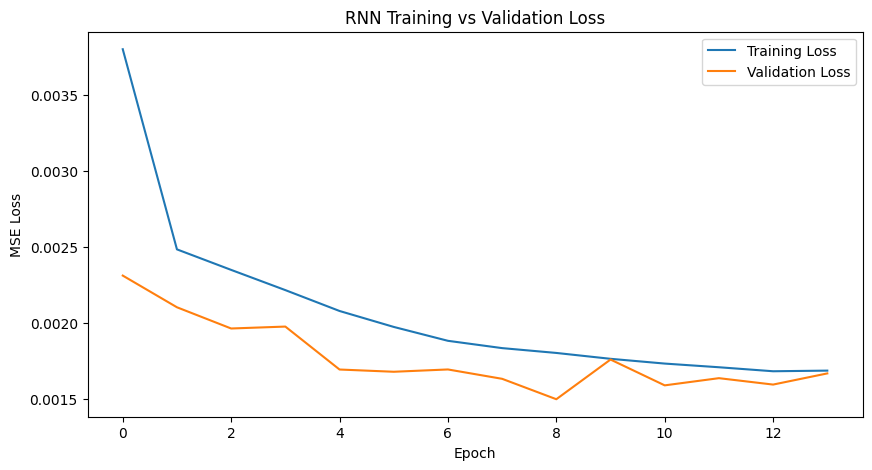

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_features.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_features.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "RNN Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()

plt.show()

In [40]:
#Build RNN + Dropout
from tensorflow.keras.layers import Dropout
def build_RNN_dropout():

    model = Sequential([
        SimpleRNN(
            64,
            input_shape=(48, 9)
        ),

        Dropout(0.2),

        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [41]:
RNN_dropout = build_RNN_dropout()

history_dropout = RNN_dropout.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 0.0062 - val_loss: 0.0021
Epoch 2/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0030 - val_loss: 0.0020
Epoch 3/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 0.0028 - val_loss: 0.0020
Epoch 4/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0028 - val_loss: 0.0020
Epoch 5/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.0028 - val_loss: 0.0020


In [42]:
pred_dropout = RNN_dropout.predict(
    X_test,
    verbose=0
)

pred_dropout = inverse_target(pred_dropout)

metrics = evaluate_forecast(
    actual_test,
    pred_dropout
)

dropout_result = {
    "Experiment": "RNN + Lag + Rolling + Dropout",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

dropout_result

{'Experiment': 'RNN + Lag + Rolling + Dropout',
 'MAE': 1720.1938767741065,
 'MSE': 5615453.809740107,
 'RMSE': np.float64(2369.694876928274),
 'MAPE': np.float64(5.518210425622043),
 'R2': 0.8666025797904865,
 'Bias': np.float64(-48.725468951346734)}

In [43]:
results.append(dropout_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline RNN,1566.645508,4.637170e+06,2153.408885,5.001122,0.889842,331.006106
1,RNN + Lag + Rolling Features,1491.115156,4.387301e+06,2094.588422,4.748388,0.895778,15.501871
2,RNN + Lag + Rolling + Dropout,1720.193877,5.615454e+06,2369.694877,5.518210,0.866603,-48.725469


In [44]:
#bATCH nORMALIZATION
from tensorflow.keras.layers import BatchNormalization
def build_RNN_batchnorm():

    model = Sequential([
        SimpleRNN(
            64,
            input_shape=(48, 9)
        ),

        BatchNormalization(),

        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [45]:
RNN_batchnorm = build_RNN_batchnorm()

history_batchnorm = RNN_batchnorm.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 0.0136 - val_loss: 0.0271
Epoch 2/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 0.0039 - val_loss: 0.0484
Epoch 3/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0033 - val_loss: 0.0115
Epoch 4/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0032 - val_loss: 0.0172
Epoch 5/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 0.0031 - val_loss: 0.0656


In [46]:
pred_batchnorm = RNN_batchnorm.predict(
    X_test,
    verbose=0
)

pred_batchnorm = inverse_target(pred_batchnorm)

metrics = evaluate_forecast(
    actual_test,
    pred_batchnorm
)

batchnorm_result = {
    "Experiment": "RNN + Lag + Rolling + BatchNorm",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

batchnorm_result

{'Experiment': 'RNN + Lag + Rolling + BatchNorm',
 'MAE': 6205.845529790234,
 'MSE': 57525245.06769455,
 'RMSE': np.float64(7584.5398718508),
 'MAPE': np.float64(21.117271335997888),
 'R2': -0.3665359112455504,
 'Bias': np.float64(3208.6936245303837)}

In [47]:
results.append(batchnorm_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline RNN,1566.645508,4.637170e+06,2153.408885,5.001122,0.889842,331.006106
1,RNN + Lag + Rolling Features,1491.115156,4.387301e+06,2094.588422,4.748388,0.895778,15.501871
2,RNN + Lag + Rolling + Dropout,1720.193877,5.615454e+06,2369.694877,5.518210,0.866603,-48.725469
3,RNN + Lag + Rolling + BatchNorm,6205.845530,5.752525e+07,7584.539872,21.117271,-0.366536,3208.693625


In [48]:
#Build RNN with RMSprop
def build_RNN_rmsprop():

    model = Sequential([
        SimpleRNN(
            64,
            input_shape=(48, 9)
        ),
        BatchNormalization(),
        Dense(24)
    ])

    model.compile(
        optimizer=RMSprop(learning_rate=0.001),
        loss="mse"
    )

    return model

In [49]:
RNN_rmsprop = build_RNN_rmsprop()

history_rmsprop = RNN_rmsprop.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 0.0112 - val_loss: 0.0161
Epoch 2/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0043 - val_loss: 0.0283
Epoch 3/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0037 - val_loss: 0.0211
Epoch 4/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 0.0033 - val_loss: 0.0158
Epoch 5/15
3605/3605 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0031 - val_loss: 0.0102


In [50]:
pred_rmsprop = RNN_rmsprop.predict(
    X_test,
    verbose=0
)

pred_rmsprop = inverse_target(pred_rmsprop)

metrics = evaluate_forecast(
    actual_test,
    pred_rmsprop
)

rmsprop_result = {
    "Experiment": "RNN + Features + BatchNorm + RMSprop",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

rmsprop_result

{'Experiment': 'RNN + Features + BatchNorm + RMSprop',
 'MAE': 4615.17705315166,
 'MSE': 31972595.974127438,
 'RMSE': np.float64(5654.431534126789),
 'MAPE': np.float64(15.175378505842676),
 'R2': 0.24047780199850455,
 'Bias': np.float64(-1108.6533581814217)}

In [51]:
results.append(rmsprop_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline RNN,1566.645508,4.637170e+06,2153.408885,5.001122,0.889842,331.006106
1,RNN + Lag + Rolling Features,1491.115156,4.387301e+06,2094.588422,4.748388,0.895778,15.501871
2,RNN + Lag + Rolling + Dropout,1720.193877,5.615454e+06,2369.694877,5.518210,0.866603,-48.725469
3,RNN + Lag + Rolling + BatchNorm,6205.845530,5.752525e+07,7584.539872,21.117271,-0.366536,3208.693625
4,RNN + Features + BatchNorm + RMSprop,4615.177053,3.197260e+07,5654.431534,15.175379,0.240478,-1108.653358


In [52]:
#LEARING RATE
from tensorflow.keras.callbacks import ReduceLROnPlateau
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [53]:
def build_RNN_scheduler():

    model = Sequential([
        SimpleRNN(
            64,
            input_shape=(48, 9)
        ),
        BatchNormalization(),
        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [57]:
RNN_scheduler = build_RNN_scheduler()

history_scheduler = RNN_scheduler.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=15,
    callbacks=[

        lr_scheduler
    ],
    verbose=1
)

Epoch 1/15
7690/7690 ━━━━━━━━━━━━━━━━━━━━ 44s 5ms/step - loss: 0.0080 - val_loss: 0.0877 - learning_rate: 0.0010
Epoch 2/15
7690/7690 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - loss: 0.0041 - val_loss: 0.0381 - learning_rate: 0.0010
Epoch 3/15
7687/7690 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0039
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7690/7690 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - loss: 0.0039 - val_loss: 0.2821 - learning_rate: 0.0010
Epoch 4/15
7690/7690 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - loss: 0.0036 - val_loss: 0.0354 - learning_rate: 5.0000e-04
Epoch 5/15
7690/7690 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - loss: 0.0035 - val_loss: 0.0083 - learning_rate: 5.0000e-04
Epoch 6/15
7690/7690 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - loss: 0.0035 - val_loss: 0.0157 - learning_rate: 5.0000e-04
Epoch 7/15
7690/7690 ━━━━━━━━━━━━━━━━━━━━ 84s 6ms/step - loss: 0.0035 - val_loss: 0.0092 - learning_rate: 5.0000e-04
Epoch 8/15
7687/7690 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - los

In [58]:
pred_scheduler = RNN_scheduler.predict(
    X_test,
    verbose=0
)

pred_scheduler = inverse_target(pred_scheduler)

metrics = evaluate_forecast(
    actual_test,
    pred_scheduler
)

scheduler_result = {
    "Experiment": "RNN + Features + BatchNorm + LR Scheduler",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

scheduler_result

{'Experiment': 'RNN + Features + BatchNorm + LR Scheduler',
 'MAE': 2212.4566452353856,
 'MSE': 8562688.543925608,
 'RMSE': np.float64(2926.2071942918888),
 'MAPE': np.float64(7.332545397180605),
 'R2': 0.7965898036885293,
 'Bias': np.float64(936.7784650195932)}

In [59]:
results.pop(5)

{'Experiment': 'RNN + Features + BatchNorm + LR Scheduler',
 'MAE': 10389.286236964088,
 'MSE': 167295074.8583628,
 'RMSE': np.float64(12934.25973368259),
 'MAPE': np.float64(34.40419789158996),
 'R2': -2.9741634703065785,
 'Bias': np.float64(-6484.379366710687)}

In [60]:
results.append(scheduler_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline RNN,1566.645508,4.637170e+06,2153.408885,5.001122,0.889842,331.006106
1,RNN + Lag + Rolling Features,1491.115156,4.387301e+06,2094.588422,4.748388,0.895778,15.501871
2,RNN + Lag + Rolling + Dropout,1720.193877,5.615454e+06,2369.694877,5.518210,0.866603,-48.725469
3,RNN + Lag + Rolling + BatchNorm,6205.845530,5.752525e+07,7584.539872,21.117271,-0.366536,3208.693625
4,RNN + Features + BatchNorm + RMSprop,4615.177053,3.197260e+07,5654.431534,15.175379,0.240478,-1108.653358
5,RNN + Features + BatchNorm + LR Scheduler,2212.456645,8.562689e+06,2926.207194,7.332545,0.796590,936.778465


In [61]:
#batch size tune
def build_RNN_batchsize():

    model = Sequential([
        SimpleRNN(64, input_shape=(48, 9)),
        BatchNormalization(),
        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [62]:
batch_sizes = [16, 64]

batch_results = []

for batch_size in batch_sizes:

    print(f"\nBatch Size: {batch_size}")

    model = build_RNN_batchsize()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=batch_size,
        callbacks=[

            lr_scheduler
        ],
        verbose=1
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    pred = inverse_target(pred)

    metrics = evaluate_forecast(
        actual_test,
        pred
    )

    batch_results.append({
        "Batch Size": batch_size,
        "MAE": metrics[0],
        "MSE": metrics[1],
        "RMSE": metrics[2],
        "MAPE": metrics[3],
        "R2": metrics[4],
        "Bias": metrics[5]
    })


Batch Size: 16
Epoch 1/10
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 43s 6ms/step - loss: 0.0100 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 2/10
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - loss: 0.0045 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 3/10
7209/7210 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0042
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - loss: 0.0041 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 4/10
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 0.0035 - val_loss: 0.0035 - learning_rate: 5.0000e-04
Epoch 5/10
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 0.0034 - val_loss: 0.0020 - learning_rate: 5.0000e-04
Epoch 6/10
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - loss: 0.0033 - val_loss: 0.0027 - learning_rate: 5.0000e-04
Epoch 7/10
7210/7210 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - loss: 0.0032 - val_loss: 0.0028 - learning_rate: 5.0000e-04
Epoch 8/10
7208/7210 ━━━━━━━━━━━━━━━━━━━━ 0

In [63]:
batch_df = pd.DataFrame(batch_results)

batch_df

,Batch Size,MAE,MSE,RMSE,MAPE,R2,Bias
0,16,1668.827336,5.193671e+06,2278.962753,5.429847,0.876622,209.114688
1,64,1911.799381,6.616319e+06,2572.220729,6.087333,0.842827,-546.284035


In [64]:
best_batch = batch_df.loc[
    batch_df["RMSE"].idxmin()
]

best_batch

,0
Batch Size,1.600000e+01
MAE,1.668827e+03
MSE,5.193671e+06
RMSE,2.278963e+03
MAPE,5.429847e+00
R2,8.766222e-01
Bias,2.091147e+02


In [65]:
best_batch_size = int(
    best_batch["Batch Size"]
)

print("Best Batch Size:", best_batch_size)

Best Batch Size: 16


In [67]:
# Find the best batch size based on lowest RMSE
best_batch = batch_df.loc[
    batch_df["RMSE"].idxmin()
]

# Get the batch size
best_batch_size = int(best_batch["Batch Size"])

# Create result
best_batch_result = {
    "Experiment": f"Best Batch Size ({best_batch_size})",
    "MAE": best_batch["MAE"],
    "MSE": best_batch["MSE"],
    "RMSE": best_batch["RMSE"],
    "MAPE": best_batch["MAPE"],
    "R2": best_batch["R2"],
    "Bias": best_batch["Bias"]
}

# Add result to the existing results list
results.append(best_batch_result)

# Convert results to DataFrame
improvement_df = pd.DataFrame(results)

improvement_df
improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline RNN,1566.645508,4.637170e+06,2153.408885,5.001122,0.889842,331.006106
1,RNN + Lag + Rolling Features,1491.115156,4.387301e+06,2094.588422,4.748388,0.895778,15.501871
2,RNN + Lag + Rolling + Dropout,1720.193877,5.615454e+06,2369.694877,5.518210,0.866603,-48.725469
3,RNN + Lag + Rolling + BatchNorm,6205.845530,5.752525e+07,7584.539872,21.117271,-0.366536,3208.693625
4,RNN + Features + BatchNorm + RMSprop,4615.177053,3.197260e+07,5654.431534,15.175379,0.240478,-1108.653358
5,RNN + Features + BatchNorm + LR Scheduler,2212.456645,8.562689e+06,2926.207194,7.332545,0.796590,936.778465
6,Best Batch Size (16),1668.827336,5.193671e+06,2278.962753,5.429847,0.876622,209.114688


In [ ]:
for i, item in enumerate(results):
    print(i, type(item), item)

0 <class 'dict'> {'Experiment': 'Phase 5 Baseline GRU', 'MAE': 1364.036036, 'MSE': 3715291, 'RMSE': 1927.508982, 'MAPE': 4.343224, 'R2': 0.911742, 'Bias': 331.006106}
1 <class 'dict'> {'Experiment': 'GRU + Lag + Rolling Features', 'MAE': 1344.7525077838422, 'MSE': 3577180.991042391, 'RMSE': np.float64(1891.3436998711766), 'MAPE': np.float64(4.282023275302831), 'R2': 0.9150156746211608, 'Bias': np.float64(218.57606111279702)}
2 <class 'dict'> {'Experiment': 'GRU + Lag + Rolling + Dropout', 'MAE': 1364.9627793883506, 'MSE': 3659960.3007556144, 'RMSE': np.float64(1913.1022713790328), 'MAPE': np.float64(4.344613251012498), 'R2': 0.9130490579448114, 'Bias': np.float64(222.82578125954507)}
3 <class 'dict'> {'Experiment': 'GRU + Lag + Rolling + BatchNorm', 'MAE': 4283.947496829238, 'MSE': 28591542.387250345, 'RMSE': np.float64(5347.105982421738), 'MAPE': np.float64(14.103206912486746), 'R2': 0.3207408438640671, 'Bias': np.float64(-295.4816516939211)}
4 <class 'dict'> {'Experiment': 'GRU + Fea

In [68]:
results

[{'Experiment': 'Phase 5 Baseline RNN',
  'MAE': 1566.645508,
  'MSE': 4637170.0,
  'RMSE': 2153.408885,
  'MAPE': 5.001122,
  'R2': 0.889842,
  'Bias': 331.006106},
 {'Experiment': 'RNN + Lag + Rolling Features',
  'MAE': 1491.1151559961988,
  'MSE': 4387300.659079611,
  'RMSE': np.float64(2094.58842235882),
  'MAPE': np.float64(4.748387877594487),
  'R2': 0.895777864188005,
  'Bias': np.float64(15.501870847174589)},
 {'Experiment': 'RNN + Lag + Rolling + Dropout',
  'MAE': 1720.1938767741065,
  'MSE': 5615453.809740107,
  'RMSE': np.float64(2369.694876928274),
  'MAPE': np.float64(5.518210425622043),
  'R2': 0.8666025797904865,
  'Bias': np.float64(-48.725468951346734)},
 {'Experiment': 'RNN + Lag + Rolling + BatchNorm',
  'MAE': 6205.845529790234,
  'MSE': 57525245.06769455,
  'RMSE': np.float64(7584.5398718508),
  'MAPE': np.float64(21.117271335997888),
  'R2': -0.3665359112455504,
  'Bias': np.float64(3208.6936245303837)},
 {'Experiment': 'RNN + Features + BatchNorm + RMSprop',
  

In [69]:
#number of layers
architectures = {
    "RNN_32": [32],

    "RNN_128": [128]
}

In [71]:
architecture_results = []

for name, units in architectures.items():

    print(f"\nTraining: {name}")

    model = Sequential()

    for i, unit in enumerate(units):

        model.add(
            SimpleRNN(
                unit,
                return_sequences=(i < len(units) - 1),
                input_shape=(48, 9) if i == 0 else None
            )
        )

    model.add(BatchNormalization())
    model.add(Dense(24))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=64,
        callbacks=[
            early_stopping,
            lr_scheduler
        ],
        verbose=1
    )

    print(f"Predicting: {name}")

    pred = model.predict(
        X_test,
        verbose=0
    )

    pred = inverse_target(pred)

    metrics = evaluate_forecast(
        actual_test,
        pred
    )

    architecture_results.append({
        "Architecture": name,
        "MAE": metrics[0],
        "MSE": metrics[1],
        "RMSE": metrics[2],
        "MAPE": metrics[3],
        "R2": metrics[4],
        "Bias": metrics[5]
    })

    print(f"Finished: {name}")


Training: RNN_32
Epoch 1/15
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 0.0274 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 2/15
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0065 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 3/15
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0047
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0044 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 4/15
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0037 - val_loss: 0.0076 - learning_rate: 5.0000e-04
Epoch 5/15
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0033 - val_loss: 0.0212 - learning_rate: 5.0000e-04
Predicting: RNN_32
Finished: RNN_32

Training: RNN_128
Epoch 1/15
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 0.0141 - val_loss: 0.1256 - learning_rate: 0.0010
Epoch 2/15
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0035 - val_loss: 0.0373 - learning_rate: 0

In [72]:
architecture_df = pd.DataFrame(
    architecture_results
)

architecture_df

,Architecture,MAE,MSE,RMSE,MAPE,R2,Bias
0,RNN_32,2998.464298,1.460395e+07,3821.511300,9.835785,0.653077,-46.691717
1,RNN_128,13294.567265,2.671661e+08,16345.215046,44.628255,-5.346640,351.773866


In [73]:
best_architecture = architecture_df.loc[
    architecture_df["RMSE"].idxmin()
]

best_architecture

,0
Architecture,RNN_32
MAE,2998.464298
MSE,14603948.6128
RMSE,3821.5113
MAPE,9.835785
R2,0.653077
Bias,-46.691717


In [74]:
results.append(scheduler_result)

improvement_df = pd.DataFrame(architecture_results)

improvement_df

,Architecture,MAE,MSE,RMSE,MAPE,R2,Bias
0,RNN_32,2998.464298,1.460395e+07,3821.511300,9.835785,0.653077,-46.691717
1,RNN_128,13294.567265,2.671661e+08,16345.215046,44.628255,-5.346640,351.773866


In [78]:
best_arch = architecture_df.loc[
    architecture_df["RMSE"].idxmin()
]

architecture_result = {
    "Experiment": f"Architecture ({best_arch['Architecture']})",
    "MAE": best_arch["MAE"],
    "MSE": best_arch["MSE"],
    "RMSE": best_arch["RMSE"],
    "MAPE": best_arch["MAPE"],
    "R2": best_arch["R2"],
    "Bias": best_arch["Bias"]
}

results.append(architecture_result)

In [79]:

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline RNN,1566.645508,4.637170e+06,2153.408885,5.001122,0.889842,331.006106
1,RNN + Lag + Rolling Features,1491.115156,4.387301e+06,2094.588422,4.748388,0.895778,15.501871
2,RNN + Lag + Rolling + Dropout,1720.193877,5.615454e+06,2369.694877,5.518210,0.866603,-48.725469
3,RNN + Lag + Rolling + BatchNorm,6205.845530,5.752525e+07,7584.539872,21.117271,-0.366536,3208.693625
4,RNN + Features + BatchNorm + RMSprop,4615.177053,3.197260e+07,5654.431534,15.175379,0.240478,-1108.653358
5,RNN + Features + BatchNorm + LR Scheduler,2212.456645,8.562689e+06,2926.207194,7.332545,0.796590,936.778465
6,Best Batch Size (16),1668.827336,5.193671e+06,2278.962753,5.429847,0.876622,209.114688
7,RNN + Features + BatchNorm + LR Scheduler,2212.456645,8.562689e+06,2926.207194,7.332545,0.796590,936.778465
8,Architecture (RNN_32),2998.464298,1.460395e+07,3821.511300,9.835785,0.653077,-46.691717
9,Architecture (RNN_32),2998.464298,1.460395e+07,3821.511300,9.835785,0.653077,-46.691717


In [81]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.5 MB/s eta 0:00:00


In [82]:
import keras_tuner as kt

In [83]:
def build_tuned_RNN(hp):

    model = Sequential()

    model.add(
        SimpleRNN(
            units=hp.Choice(
                "RNN_units",
                [32, 64, 128]
            ),
            input_shape=(48, 9)
        )
    )

    model.add(
        Dropout(
            hp.Float(
                "dropout",
                0.1,
                0.4,
                step=0.1
            )
        )
    )

    model.add(Dense(24))

    optimizer_name = hp.Choice(
        "optimizer",
        ["adam", "rmsprop"]
    )

    learning_rate = hp.Choice(
        "learning_rate",
        [0.001, 0.0005, 0.0001]
    )

    if optimizer_name == "adam":
        optimizer = Adam(
            learning_rate=learning_rate
        )
    else:
        optimizer = RMSprop(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="mse"
    )

    return model

In [84]:
tuner = kt.RandomSearch(
    build_tuned_RNN,

    objective="val_loss",

    max_trials=3,

    directory="phase6_tuning",

    project_name="RNN_forecasting",

    overwrite=True
)

In [85]:
tuner.search(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=15,

    batch_size=best_batch_size,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Trial 3 Complete [00h 03m 27s]
val_loss: 0.0019149415893480182

Best val_loss So Far: 0.0018803876591846347
Total elapsed time: 00h 10m 19s


In [86]:
best_hp = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

print(
    "RNN Units:",
    best_hp.get("RNN_units")
)

print(
    "Dropout:",
    best_hp.get("dropout")
)

print(
    "Optimizer:",
    best_hp.get("optimizer")
)

print(
    "Learning Rate:",
    best_hp.get("learning_rate")
)

RNN Units: 128
Dropout: 0.1
Optimizer: rmsprop
Learning Rate: 0.001


In [87]:
best_model = tuner.get_best_models(
    num_models=1
)[0]

In [88]:
pred_tuned = best_model.predict(
    X_test,
    verbose=0
)

pred_tuned = inverse_target(
    pred_tuned
)

metrics = evaluate_forecast(
    actual_test,
    pred_tuned
)

tuned_result = {
    "Experiment": "RNN Hyperparameter Tuning",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

tuned_result

{'Experiment': 'RNN Hyperparameter Tuning',
 'MAE': 1678.0239579748475,
 'MSE': 5454398.099204551,
 'RMSE': np.float64(2335.4652853777447),
 'MAPE': np.float64(5.396289308111567),
 'R2': 0.8704285245891399,
 'Bias': np.float64(206.42347234044587)}

In [89]:
results.append(tuned_result)

final_results = pd.DataFrame(results)

final_results

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline RNN,1566.645508,4.637170e+06,2153.408885,5.001122,0.889842,331.006106
1,RNN + Lag + Rolling Features,1491.115156,4.387301e+06,2094.588422,4.748388,0.895778,15.501871
2,RNN + Lag + Rolling + Dropout,1720.193877,5.615454e+06,2369.694877,5.518210,0.866603,-48.725469
3,RNN + Lag + Rolling + BatchNorm,6205.845530,5.752525e+07,7584.539872,21.117271,-0.366536,3208.693625
4,RNN + Features + BatchNorm + RMSprop,4615.177053,3.197260e+07,5654.431534,15.175379,0.240478,-1108.653358
5,RNN + Features + BatchNorm + LR Scheduler,2212.456645,8.562689e+06,2926.207194,7.332545,0.796590,936.778465
6,Best Batch Size (16),1668.827336,5.193671e+06,2278.962753,5.429847,0.876622,209.114688
7,RNN + Features + BatchNorm + LR Scheduler,2212.456645,8.562689e+06,2926.207194,7.332545,0.796590,936.778465
8,Architecture (RNN_32),2998.464298,1.460395e+07,3821.511300,9.835785,0.653077,-46.691717
9,Architecture (RNN_32),2998.464298,1.460395e+07,3821.511300,9.835785,0.653077,-46.691717


In [90]:
final_results = pd.DataFrame(results)

final_results.sort_values(
    "RMSE"
)

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
1,RNN + Lag + Rolling Features,1491.115156,4.387301e+06,2094.588422,4.748388,0.895778,15.501871
0,Phase 5 Baseline RNN,1566.645508,4.637170e+06,2153.408885,5.001122,0.889842,331.006106
6,Best Batch Size (16),1668.827336,5.193671e+06,2278.962753,5.429847,0.876622,209.114688
10,RNN Hyperparameter Tuning,1678.023958,5.454398e+06,2335.465285,5.396289,0.870429,206.423472
2,RNN + Lag + Rolling + Dropout,1720.193877,5.615454e+06,2369.694877,5.518210,0.866603,-48.725469
7,RNN + Features + BatchNorm + LR Scheduler,2212.456645,8.562689e+06,2926.207194,7.332545,0.796590,936.778465
5,RNN + Features + BatchNorm + LR Scheduler,2212.456645,8.562689e+06,2926.207194,7.332545,0.796590,936.778465
8,Architecture (RNN_32),2998.464298,1.460395e+07,3821.511300,9.835785,0.653077,-46.691717
9,Architecture (RNN_32),2998.464298,1.460395e+07,3821.511300,9.835785,0.653077,-46.691717
4,RNN + Features + BatchNorm + RMSprop,4615.177053,3.197260e+07,5654.431534,15.175379,0.240478,-1108.653358


In [91]:
best_result = final_results.loc[
    final_results["RMSE"].idxmin()
]

best_result

,1
Experiment,RNN + Lag + Rolling Features
MAE,1491.115156
MSE,4387300.65908
RMSE,2094.588422
MAPE,4.748388
R2,0.895778
Bias,15.501871


In [104]:
best_rmse = best_result["RMSE"]
best_mae = best_result["MAE"]
best_mape = best_result["MAPE"]
best_r2 = best_result["R2"]

In [111]:

baseline_rmse = 2153.408885
baseline_mae =  1566.645508
baseline_mape =5.001122
baseline_r2 = 0.889842



In [112]:
rmse_improvement = (
    (baseline_rmse - best_rmse)
    / baseline_rmse
) * 100

print(f"RMSE Improvement: {rmse_improvement:.2f}%")

RMSE Improvement: 2.73%


In [113]:
comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "MAPE",
        "R2"
    ],

    "Phase 5 Baseline": [
        baseline_mae,
        baseline_rmse,
        baseline_mape,
        baseline_r2
    ],

    "Phase 6 Final": [
        best_mae,
        best_rmse,
        best_mape,
        best_r2
    ]
})

comparison

,Metric,Phase 5 Baseline,Phase 6 Final
0,MAE,1566.645508,1491.115156
1,RMSE,2153.408885,2094.588422
2,MAPE,5.001122,4.748388
3,R2,0.889842,0.895778


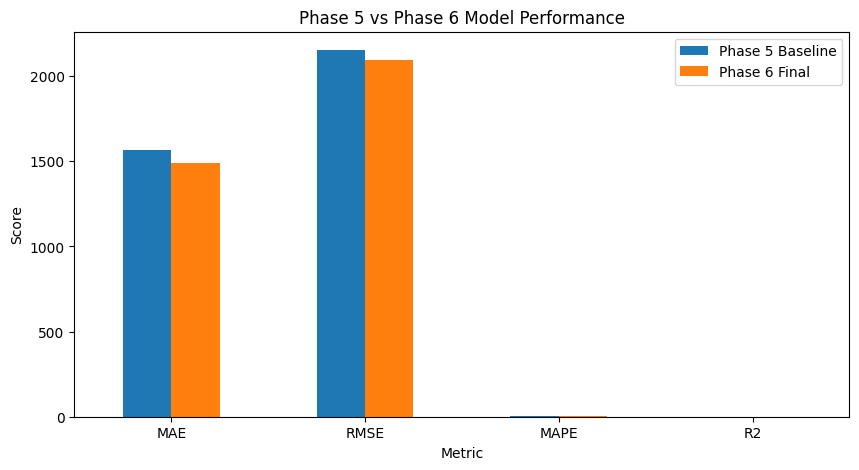

In [114]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Phase 5 vs Phase 6 Model Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [115]:
best_model.save(
    "final_RNN_forecasting_model.keras"
)

In [116]:
final_results.to_csv(
    "phase6_model_improvement_results.csv",
    index=False
)

In [117]:
comparison.to_csv(
    "phase5_vs_phase6_comparison.csv",
    index=False
)